In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 5** - Chemical Process Optimisation (4D)

- A black-box function representing the yield of a chemical process in a factory. 
- The function is typically unimodal, one peak, no traps.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield.

**Input** - 4D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 6605.98 at [0.871, 0.993, 1.000, 1.000] (Week 11)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

# New data for Week 12 (Function 5)
X_w12_new_point = np.array([0.990432, 0.741174, 0.968413, 0.995092], dtype=np.float64)
Y_w12_new_point = np.array([4923.8224082617135], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 5:', X_unique)
print('Updated Outputs (Y) - Function 5:', Y_updated)

Updated Inputs (X) - Function 5: [[0.004861   0.982935   0.98162    0.958237  ]
 [0.028538   0.096927   0.128764   0.401407  ]
 [0.114475   0.992539   0.999989   0.525254  ]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.221849   0.896815   0.894595   0.898055  ]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.4

## **Output Analysis**

- **w11 Output:** 6605.98 (all-time best)
- **w12 Output:** 4923.82 at [0.990, 0.741, 0.968, 0.995] which is a regression

- **Comparison:** A significant regression from the all-time best. The critical issue: x2 dropped from 0.993 to 0.741 which is a collapse of 0.252 units. 
    - This is the same pattern seen in w9 when x2 dropped and yield halved. 
    - x2 is clearly the most sensitive dimension for this function: it must stay above 0.95 to maintain high yields.

- **Real-World Implication:** In chemical engineering, this confirms x2 represents a critical reaction condition (temperature, pressure, or catalyst loading) that has a hard threshold effect. 
    - Below ~0.90, the reaction leaves its optimal kinetic regime regardless of how well other parameters are set.

- **Model Clues:** w13 must return x2 to near 1.000 and re-centre on the w11 all-time best [0.871, 0.993, 1.000, 1.000]. 

- The w12 regression is boundary evidence, not a reason to change strategy but it simply confirms x2 must not drop below 0.95.

## **Bayesian Optimisation** - Gaussian Processes

- The Matérn (ν=2.5) + WhiteKernel GP is retained. 
    - The smooth, differentiable ν=2.5 kernel is the correct choice for a confirmed unimodal function as the chemical yield surface is continuous and well-behaved, with no discontinuities. 
    - A rougher kernel would introduce unnecessary local variation that would mislead the acquisition function in the high-yield boundary region where x2, x3, x4 are all near 1.000. 
    
- The WhiteKernel captures small experimental variability in yield measurements.

- This week introduces a new hard constraint: x2 ≥ 0.95 applied to all candidate points before acquisition. 
    - This is the most significant methodological change for F5 in recent weeks. 
    
    - The evidence justifying it is unambiguous: w9 had x2=0.489, yield dropped to 3445; w12 had x2=0.741, yield dropped to 4923. 
        - The w11 all-time best had x2=0.993, yield 6605. 
        
- The GP's internal length scale for x2 should already be very short (high sensitivity), but constraint enforcement ensures the acquisition function cannot recommend a candidate with x2 below the empirically established safe threshold regardless of what the GP predicts. 
    - This mirrors best practice in constrained Bayesian optimisation, where known feasibility constraints are enforced explicitly rather than left to the model to rediscover.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [3.47588113e+03 1.42925081e+02 1.72816974e+03 4.31612757e+02
 9.97233189e+00 8.84799176e+00 6.44434399e+01 1.52269614e+03
 1.08885962e+03 1.33955718e+03 6.34767158e+01 1.09571876e+02
 4.51815703e+01 1.12939795e-01 3.55806818e+02 2.33223610e+02
 7.97291299e+01 5.75715369e+01 1.55727657e+02 6.44201468e+01
 2.44230883e+01 7.84343889e+01 4.21089813e+00 2.88667516e+01
 1.83013796e+01 2.58370525e+02 5.22126375e+03 6.20349673e+03
 5.89609014e+03 6.60598381e+03 3.44506661e+03 4.92382241e+03]
Transformed Y: [ 1.23048422 -0.19630785  0.90809714  0.28443838 -1.27209981 -1.31584113
 -0.53282036  0.85028873  0.69800989  0.7919506  -0.53911357 -0.30958576
 -0.6796442  -2.17408792  0.1993617   0.01484603 -0.44381336 -0.57967828
 -0.1595369  -0.53297093 -0.92820642 -0.45068494 -1.57107906 -0.86148027
 -1.04171804  0.0593794   1.42075473  1.50192917  1.4779599   1.53161717
  1.22634122  1.39321053]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- EI with ξ=0.0005 is retained. 
    - At the yield levels achieved (6605), the improvement per query is becoming smaller, we are in the asymptotic region near the unimodal peak. 
    
    - A very small ξ=0.0005 tells EI to pursue even marginal improvements over 6605, which is correct because we know the function is smooth and unimodal.
    
- The 95/5 focused-to-uniform split is the most aggressive exploitation ratio used in this project, justified by the confirmed unimodal structure. 

- The std=0.008 keeps all candidate samples within ±0.016 of the w11 best in 95% of cases which probes whether x1 can be pushed slightly higher (current trend: 0.843→0.846→0.871) while all other dimensions hold near their maximum values.

In [4]:
def expected_improvement(X, model, y_max, xi=0.0005):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.871213, 0.992883, 1.0, 1.0])

x_focused = np.random.normal(loc=w_best, scale=0.008, size=(9500, 4))
x_uniform = np.random.uniform(0, 1, size=(500, 4))
x_grid = np.vstack([x_focused, x_uniform])
# Hard floor: x2 >= 0.95 — W9 and W12 regressions caused by x2 collapse
x_grid[:, 1] = np.maximum(x_grid[:, 1], 0.95)
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.0005)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Week 13 Query Recommendation (Function 5): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

Best coordinates: [0.871213 0.992883 1.       1.      ]
Week 13 Query Recommendation (Function 5): 0.895175-1.000000-1.000000-1.000000


## **Visualisation**

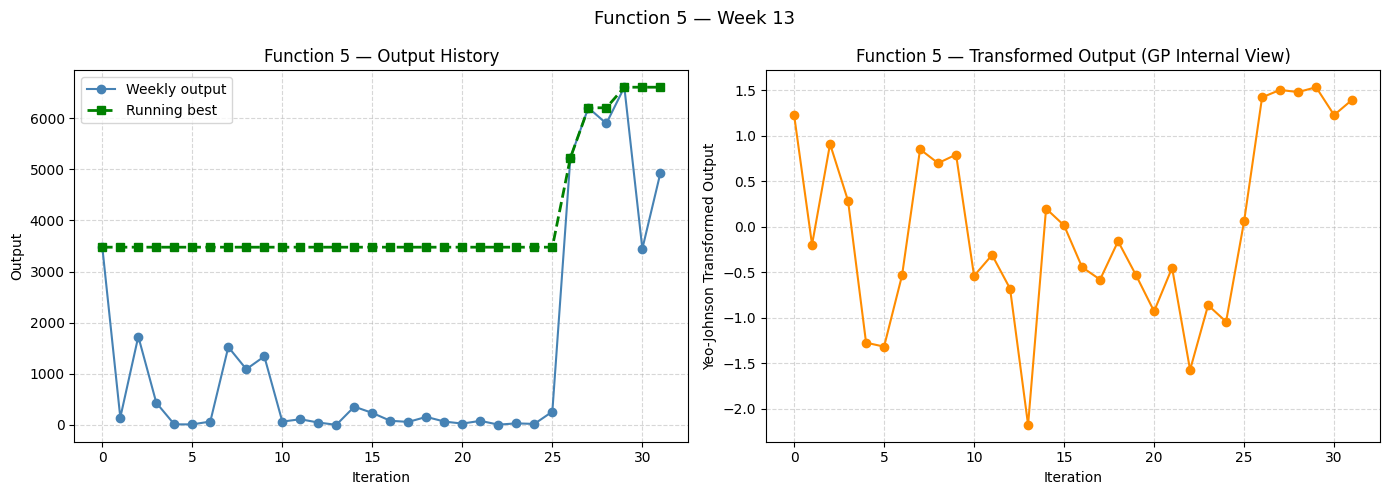

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 5 — Output History')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 5 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 5 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()